## Step 01: Setup Environment

In [5]:
#check the python version and env and the pytorch version
import sys
import torch

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)


Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
PyTorch version: 2.5.1


## Step 02: Exploratory Data Analysis

In [12]:
#load the tex file and print the first 100 characters

print("Loading data...")
print("====================================================================")
print("Train data:")
print("====================================================================")
with open("./data/train.txt", "r") as f:
    data = f.read()
    print(data[:100])


print("====================================================================")
print("Validation data:")
print("====================================================================")
with open("./data/val.txt", "r") as f:
    data = f.read()
    print(data[:100])

print("====================================================================")
print("Test data:")
print("====================================================================")
with open("./data/test.txt", "r") as f:
    data = f.read()
    print(data[:100])

Loading data...
Train data:
Selegiline	O
-	O
induced	O
postural	B-Disease
hypotension	I-Disease
in	O
Parkinson	B-Disease
'	I-Dis
Validation data:
22	O
-	O
oxacalcitriol	O
suppresses	O
secondary	B-Disease
hyperparathyroidism	I-Disease
without	O
in
Test data:
Torsade	B-Disease
de	I-Disease
pointes	I-Disease
ventricular	B-Disease
tachycardia	I-Disease
during	


In [13]:
import os
import json

def parse_ner_file(file_path):
  
    sentences = []
    current_words = []
    current_labels = []
    
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            
            
            if not line:
                if current_words:
                    sentences.append({
                        "words": current_words,
                        "labels": current_labels
                    })
                    current_words = []
                    current_labels = []
                continue
            
        
            parts = line.split()
            if len(parts) >= 2:
                word = parts[0]
                label = parts[-1] 
                current_words.append(word)
                current_labels.append(label)
                
        
        if current_words:
            sentences.append({
                "words": current_words,
                "labels": current_labels
            })
            
    return sentences


In [ ]:
# --- Main Execution ---
data_dir = "./data"
output_dir = "./processed_base_data"
os.makedirs(output_dir, exist_ok=True)

files_to_process = ["train.txt", "val.txt", "test.txt"]

for file_name in files_to_process:
    input_path = os.path.join(data_dir, file_name)
    
    if os.path.exists(input_path):
        print(f"Processing {file_name}...")
        parsed_data = parse_ner_file(input_path)
        
        output_name = file_name.replace(".txt", ".json")
        output_path = os.path.join(output_dir, output_name)
        
        with open(output_path, "w", encoding="utf-8") as out_f:
            json.dump(parsed_data, out_f, indent=4)
            
        print(f"Successfully saved {len(parsed_data)} sentences to {output_path}")
    else:
        print(f"Error: {input_path} !")

print("====================================================================")
print("Base Data Preparation Done!")

Processing train.txt...
Successfully saved 4560 sentences to ./processed_base_data\train.json
Processing val.txt...
Successfully saved 4581 sentences to ./processed_base_data\val.json
Processing test.txt...
Successfully saved 4797 sentences to ./processed_base_data\test.json
Base Data Preparation Done!


In [17]:
with open("./processed_base_data/train.json", "r") as f:
    train_dataset = json.load(f)

print("First Sentence Words:", train_dataset[0]["words"])
print("First Sentence Labels:", train_dataset[0]["labels"])

First Sentence Words: ['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']
First Sentence Labels: ['O', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [18]:
import json
import os

# Define the file paths for verification
data_files = {
    "Train Data": "./processed_base_data/train.json",
    "Validation Data": "./processed_base_data/val.json",
    "Test Data": "./processed_base_data/test.json"
}

print("Starting structural validation for dataset splits...")
print("====================================================================")

all_splits_valid = True

for split_name, file_path in data_files.items():
    if not os.path.exists(file_path):
        print(f"Warning: {split_name} file not found at {file_path}. Skipping...")
        continue
        
    print(f"Verifying {split_name}...")
    
    # Load the processed JSON data
    with open(file_path, "r", encoding="utf-8") as f:
        dataset = json.load(f)
        
    mismatched_sentences_count = 0
    total_sentences = len(dataset)
    
    # Loop through each sentence to check lengths
    for index, sample in enumerate(dataset):
        word_length = len(sample["words"])
        label_length = len(sample["labels"])
        
        # Check if the length of words matches the length of labels
        if word_length != label_length:
            print(f"  [Error] Mismatch found at sentence index {index}!")
            print(f"  Words ({word_length}): {sample['words']}")
            print(f"  Labels ({label_length}): {sample['labels']}")
            print("-" * 50)
            mismatched_sentences_count += 1
            all_splits_valid = False

    # Print summary statistics for the current split
    if mismatched_sentences_count == 0:
        print(f"  [Success] All {total_sentences} sentences are structurally sound.")
        print(f"  --> Word count and Tag count match perfectly for all sequences.")
    else:
        print(f"  [Failure] Found {mismatched_sentences_count} mismatched sequences out of {total_sentences}.")
        
    print("====================================================================")

# Final confirmation block
if all_splits_valid:
    print("Status Check: PASSED. Datasets are ready for the embedding pipelines!")
else:
    print("Status Check: FAILED. Please resolve the mismatched lengths before proceeding.")

Starting structural validation for dataset splits...
Verifying Train Data...
  [Success] All 4560 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Verifying Validation Data...
  [Success] All 4581 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Verifying Test Data...
  [Success] All 4797 sentences are structurally sound.
  --> Word count and Tag count match perfectly for all sequences.
Status Check: PASSED. Datasets are ready for the embedding pipelines!


C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2068258694.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), ax=axes[0], palette="viridis")
C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2068258694.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Frequency", y="Tag", data=tag_df, ax=axes[2], palette="magma")


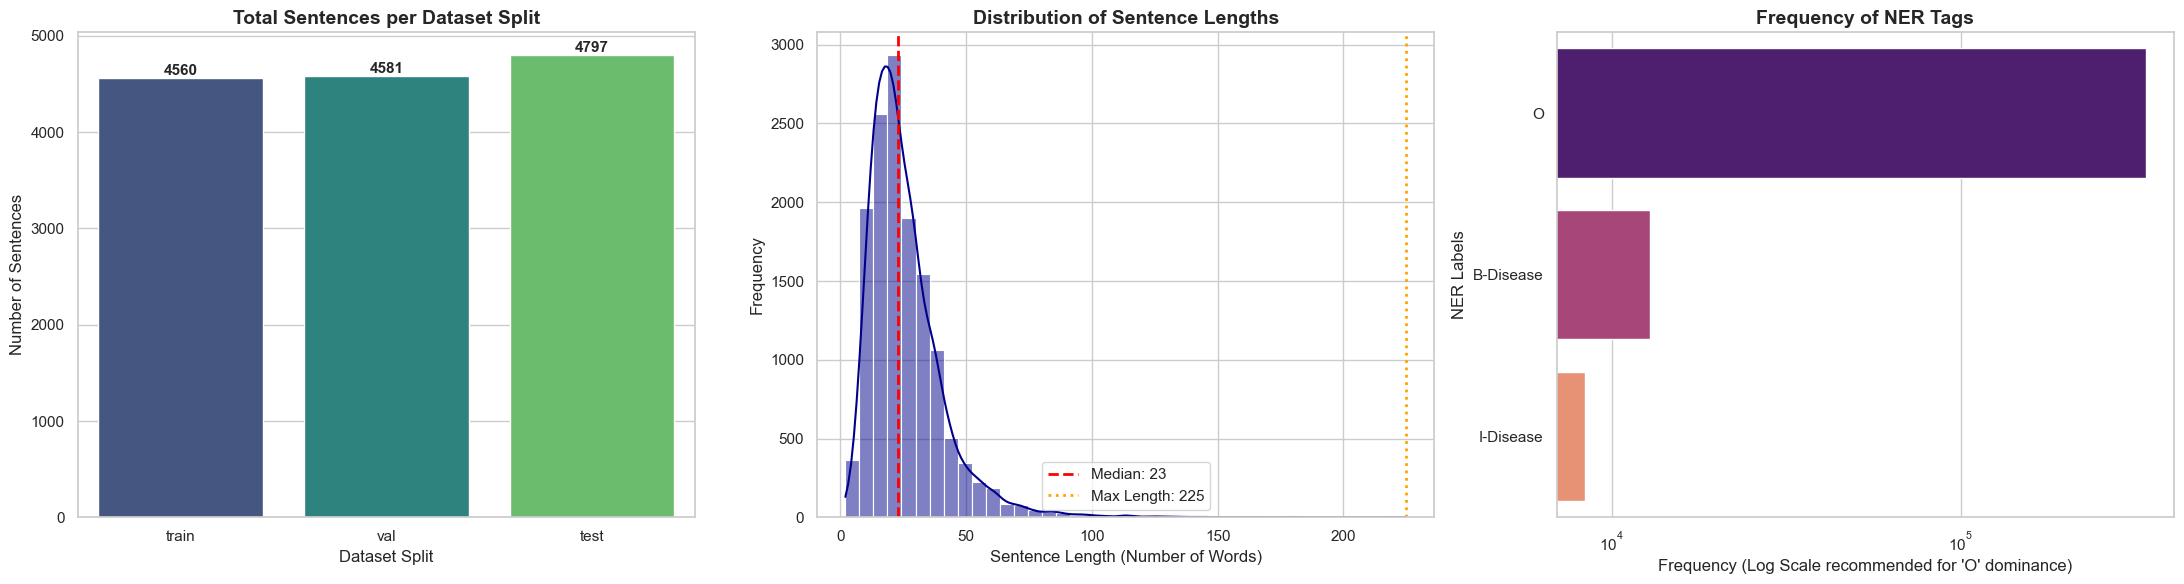

Data Insights Summary Table:
Total Combined Sentences : 13938
Maximum Sentence Length  : 225 words
Median Sentence Length   : 23 words
--------------------------------------------------------------------
NER Tag Frequencies:
  O            : 339,143 occurrences
  B-Disease    : 12,852 occurrences
  I-Disease    : 8,378 occurrences


In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# 1. Load all processed JSON datasets
splits = ["train", "val", "test"]
datasets = {}

for split in splits:
    with open(f"./processed_base_data/{split}.json", "r", encoding="utf-8") as f:
        datasets[split] = json.load(f)

# 2. Extract statistics for plotting
split_counts = {split: len(datasets[split]) for split in splits}

sentence_lengths = []
all_tags = []

for split in splits:
    for sample in datasets[split]:
        # Track sequence lengths (word counts)
        sentence_lengths.append(len(sample["words"]))
        # Track all NER tags (excluding structural symbols if any, but keeping standard tags)
        all_tags.extend(sample["labels"])

# Convert tag list to a frequency distribution dictionary
tag_counts = Counter(all_tags)

# 3. Setup the plotting canvas (3 distinct subplots)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Plot A: Total Sentence Count per Dataset Split ---
sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), ax=axes[0], palette="viridis")
axes[0].set_title("Total Sentences per Dataset Split", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Dataset Split", fontsize=12)
axes[0].set_ylabel("Number of Sentences", fontsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", label_type="edge", fontsize=11, fontweight="bold")

# --- Plot B: Sentence Length Distribution (Sequence Length Analysis) ---
sns.histplot(sentence_lengths, bins=40, kde=True, ax=axes[1], color="darkblue")
axes[1].set_title("Distribution of Sentence Lengths", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Sentence Length (Number of Words)", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

# Calculate and overlay median/max sequence stats
median_len = pd.Series(sentence_lengths).median()
max_len = max(sentence_lengths)
axes[1].axvline(median_len, color="red", linestyle="--", linewidth=2, label=f"Median: {int(median_len)}")
axes[1].axvline(max_len, color="orange", linestyle=":", linewidth=2, label=f"Max Length: {max_len}")
axes[1].legend(fontsize=11)

# --- Plot C: NER Label/Tag Distribution Frequency ---
# Convert to DataFrame for easier plotting with Seaborn
tag_df = pd.DataFrame(tag_counts.items(), columns=["Tag", "Frequency"]).sort_values(by="Frequency", ascending=False)
sns.barplot(x="Frequency", y="Tag", data=tag_df, ax=axes[2], palette="magma")
axes[2].set_title("Frequency of NER Tags", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Frequency (Log Scale recommended for 'O' dominance)", fontsize=12)
axes[2].set_ylabel("NER Labels", fontsize=12)
axes[2].set_xscale("log")  # Using log scale since 'O' tags completely dominate entity tags

# 4. Render and adjust layout
plt.tight_layout()
plt.show()

# 5. Print a quick text summary for confirmation
print("====================================================================")
print("Data Insights Summary Table:")
print("====================================================================")
print(f"Total Combined Sentences : {sum(split_counts.values())}")
print(f"Maximum Sentence Length  : {max_len} words")
print(f"Median Sentence Length   : {int(median_len)} words")
print("--------------------------------------------------------------------")
print("NER Tag Frequencies:")
for tag, count in tag_df.values:
    print(f"  {tag:<12} : {count:,} occurrences")
print("====================================================================")

## Step 03: Tokenization

In [4]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ravin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [5]:
import os
import json
import pickle
from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer

print("Initializing tokenization and label alignment pipeline...")
print("====================================================================")

# Load the standard BERT tokenizer
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Define target splits and directories
target_splits = ["train", "val", "test"]
output_base_dir = "./tokenized_data"

# Create separate subdirectories for each tokenizer type
tokenizer_types = ["whitespace", "nltk", "wordpiece"]
for t_type in tokenizer_types:
    os.makedirs(os.path.join(output_base_dir, t_type), exist_ok=True)

# Loop through each dataset split (Train, Val, Test)
for split in target_splits:
    input_file_path = f"./processed_base_data/{split}.json"
    
    if not os.path.exists(input_file_path):
        print(f"Warning: Base file {input_file_path} not found. Skipping...")
        continue
        
    print(f"Processing split: '{split}'...")
    
    with open(input_file_path, "r", encoding="utf-8") as f:
        sentences_data = json.load(f)
        
    whitespace_records = []
    nltk_records = []
    wordpiece_records = []
    
    for record in sentences_data:
        raw_words = record["words"]
        raw_labels = record["labels"]
        
        # Reconstruct original sentence sequence from list of words
        raw_sentence_string = " ".join(raw_words)
        
        # -----------------------------------------------------------------
        # 1. Pipeline: Whitespace Tokenization
        # -----------------------------------------------------------------
        whitespace_tokens = raw_sentence_string.split()
        whitespace_labels = raw_labels[:len(whitespace_tokens)]
        whitespace_records.append({"tokens": whitespace_tokens, "labels": whitespace_labels})
        
        # -----------------------------------------------------------------
        # 2. Pipeline: NLTK Tokenization
        # -----------------------------------------------------------------
        nltk_tokens = word_tokenize(raw_sentence_string)
        nltk_labels = []
        word_index = 0
        for token in nltk_tokens:
            if word_index < len(raw_labels):
                nltk_labels.append(raw_labels[word_index])
                word_index += 1
            else:
                nltk_labels.append("O")
        nltk_records.append({"tokens": nltk_tokens, "labels": nltk_labels})
        
        # -----------------------------------------------------------------
        # 3. Pipeline: BERT WordPiece Tokenization (Sub-word Alignment with I- Tags)
        # -----------------------------------------------------------------
        tokenized_input = bert_tokenizer(raw_sentence_string, is_split_into_words=False)
        wordpiece_tokens = bert_tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
        word_ids = tokenized_input.word_ids()
        
        wordpiece_labels = []
        previous_word_idx = None
        
        for word_idx in word_ids:
            if word_idx is None:
                # Assign 'O' to BERT special tokens ([CLS], [SEP])
                wordpiece_labels.append("O")
            elif word_idx != previous_word_idx:
                # First sub-word token retains the original entity tag
                wordpiece_labels.append(raw_labels[word_idx])
            else:
                # Subsequent sub-word fragments are converted to 'I-' tags
                original_tag = raw_labels[word_idx]
                if original_tag.startswith("B-"):
                    # Convert B-Disease to I-Disease for alignment continuity
                    wordpiece_labels.append("I-" + original_tag[2:])
                else:
                    wordpiece_labels.append(original_tag)
            previous_word_idx = word_idx
            
        wordpiece_records.append({"tokens": wordpiece_tokens, "labels": wordpiece_labels})
        
    # Serialize and save the processed lists to disk
    with open(f"{output_base_dir}/whitespace/{split}.pkl", "wb") as out_f:
        pickle.dump(whitespace_records, out_f)
        
    with open(f"{output_base_dir}/nltk/{split}.pkl", "wb") as out_f:
        pickle.dump(nltk_records, out_f)
        
    with open(f"{output_base_dir}/wordpiece/{split}.pkl", "wb") as out_f:
        pickle.dump(wordpiece_records, out_f)
        
    print(f"  --> Successfully saved pickle objects for '{split}' split.")
    print("-" * 50)

print("Pipeline execution completed successfully. All artifacts are serialized!")

Initializing tokenization and label alignment pipeline...
Processing split: 'train'...
  --> Successfully saved pickle objects for 'train' split.
--------------------------------------------------
Processing split: 'val'...
  --> Successfully saved pickle objects for 'val' split.
--------------------------------------------------
Processing split: 'test'...
  --> Successfully saved pickle objects for 'test' split.
--------------------------------------------------
Pipeline execution completed successfully. All artifacts are serialized!


In [6]:
import pickle
import os

# Define the directory structure to scan and verify
base_serialized_dir = "./tokenized_data"
tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
dataset_splits = ["train", "val", "test"]

print("Starting deep structure verification on serialized pickle artifacts...")
print("====================================================================")

global_pipeline_valid = True

# Iterate through each tokenizer directory
for tokenizer in tokenizer_pipelines:
    print(f"Checking Pipeline: {tokenizer.upper()}")
    print("-" * 50)
    
    for split in dataset_splits:
        file_path = os.path.join(base_serialized_dir, tokenizer, f"{split}.pkl")
        
        if not os.path.exists(file_path):
            print(f"  [Warning] File missing: {file_path}")
            continue
            
        # Load the serialized data records
        with open(file_path, "rb") as f:
            serialized_records = pickle.load(f)
            
        mismatch_count = 0
        total_records = len(serialized_records)
        
        # Verify sequence continuity for every single token-label pair
        for idx, record in enumerate(serialized_records):
            token_count = len(record["tokens"])
            label_count = len(record["labels"])
            
            if token_count != label_count:
                print(f"    [Length Mismatch] Found at {split}.pkl | Index: {idx}")
                print(f"    Tokens ({token_count}): {record['tokens'][:5]}...")
                print(f"    Labels ({label_count}): {record['labels'][:5]}...")
                mismatch_count += 1
                global_pipeline_valid = False
                
        # Print results summary for this specific file
        if mismatch_count == 0:
            print(f"  --> Split '{split:<5}' : PASSED (All {total_records:,} sequences match perfectly).")
        else:
            print(f"  --> Split '{split:<5}' : FAILED ({mismatch_count} anomalies detected out of {total_records:,}).")
            
    print("====================================================================")

# Final pipeline validation response
if global_pipeline_valid:
    print("Verification Status: ALL PASSED. Token-Label counts are perfectly synced across all 3 pipelines!")
else:
    print("Verification Status: ERROR DETECTED. Please check the mismatches reported above.")

Starting deep structure verification on serialized pickle artifacts...
Checking Pipeline: WHITESPACE
--------------------------------------------------
  --> Split 'train' : PASSED (All 4,560 sequences match perfectly).
  --> Split 'val  ' : PASSED (All 4,581 sequences match perfectly).
  --> Split 'test ' : PASSED (All 4,797 sequences match perfectly).
Checking Pipeline: NLTK
--------------------------------------------------
  --> Split 'train' : PASSED (All 4,560 sequences match perfectly).
  --> Split 'val  ' : PASSED (All 4,581 sequences match perfectly).
  --> Split 'test ' : PASSED (All 4,797 sequences match perfectly).
Checking Pipeline: WORDPIECE
--------------------------------------------------
  --> Split 'train' : PASSED (All 4,560 sequences match perfectly).
  --> Split 'val  ' : PASSED (All 4,581 sequences match perfectly).
  --> Split 'test ' : PASSED (All 4,797 sequences match perfectly).
Verification Status: ALL PASSED. Token-Label counts are perfectly synced across a

Analyzing tokenized artifacts for Exploratory Data Analysis...


C:\Users\Ravin\AppData\Local\Temp\ipykernel_13180\2760088588.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(vocab_stats.keys()), y=list(vocab_stats.values()), ax=axes[0], palette="coolwarm")


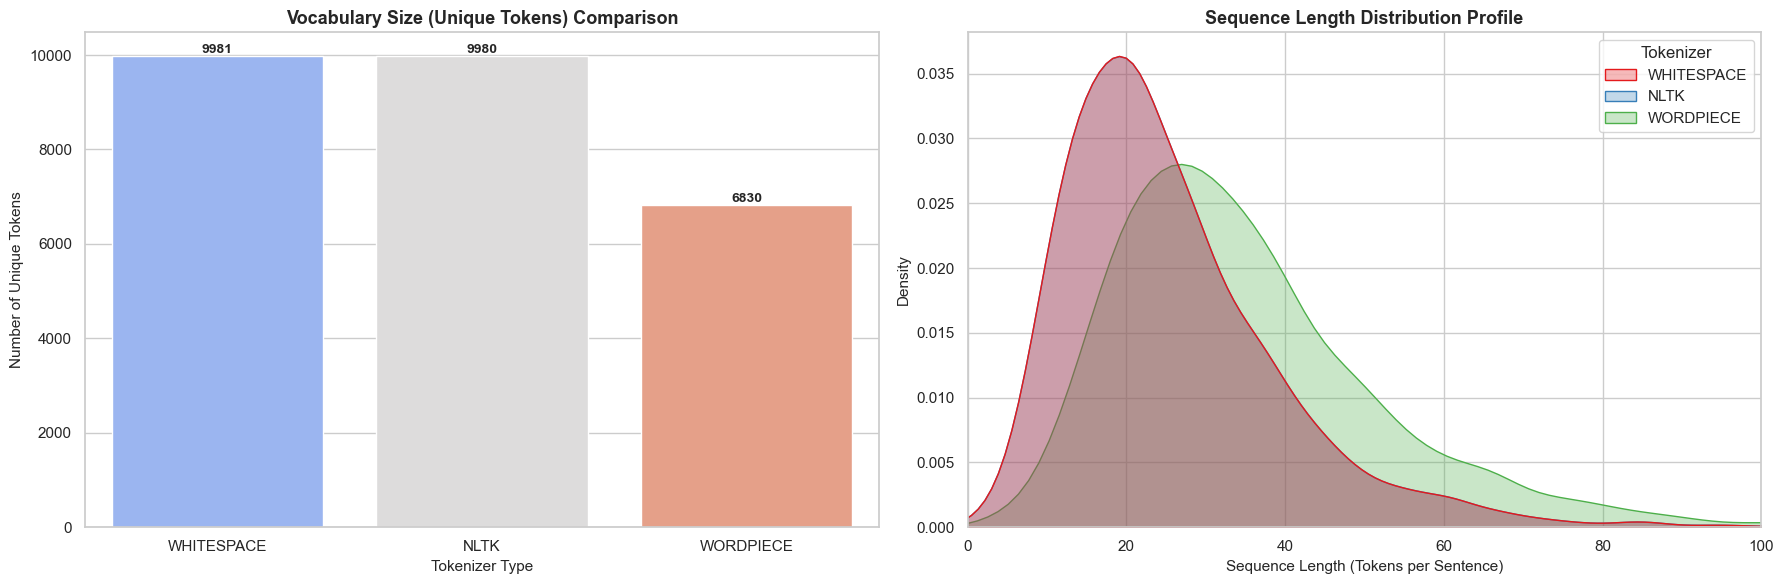

Tokenization Profile Insights Table:
Tokenizer: WHITESPACE 
  -> Unique Vocabulary Size : 9,981
  -> Median Sequence Length : 23 tokens
  -> Maximum Sequence Length: 154 tokens
--------------------------------------------------
Tokenizer: NLTK       
  -> Unique Vocabulary Size : 9,980
  -> Median Sequence Length : 23 tokens
  -> Maximum Sequence Length: 154 tokens
--------------------------------------------------
Tokenizer: WORDPIECE  
  -> Unique Vocabulary Size : 6,830
  -> Median Sequence Length : 32 tokens
  -> Maximum Sequence Length: 239 tokens
--------------------------------------------------


In [7]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define paths for the tokenized train splits
base_serialized_dir = "./tokenized_data"
tokenizer_pipelines = ["whitespace", "nltk", "wordpiece"]
split_name = "train"

# Data structures to collect insights
vocab_stats = {}
length_records = []

print("Analyzing tokenized artifacts for Exploratory Data Analysis...")
print("====================================================================")

for tokenizer in tokenizer_pipelines:
    file_path = os.path.join(base_serialized_dir, tokenizer, f"{split_name}.pkl")
    
    with open(file_path, "rb") as f:
        records = pickle.load(f)
        
    unique_tokens = set()
    
    for record in records:
        tokens_list = record["tokens"]
        # Track sequence length for this sentence
        length_records.append({
            "Tokenizer": tokenizer.upper(),
            "Sequence Length": len(tokens_list)
        })
        # Add tokens to set to calculate unique vocabulary size
        for token in tokens_list:
            unique_tokens.add(token)
            
    vocab_stats[tokenizer.upper()] = len(unique_tokens)

# Convert sequence lengths to a Pandas DataFrame for plotting
df_lengths = pd.DataFrame(length_records)

# Setup plotting canvas with 2 subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot A: Vocabulary Size Comparison across Tokenizers ---
sns.barplot(x=list(vocab_stats.keys()), y=list(vocab_stats.values()), ax=axes[0], palette="coolwarm")
axes[0].set_title("Vocabulary Size (Unique Tokens) Comparison", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tokenizer Type", fontsize=11)
axes[0].set_ylabel("Number of Unique Tokens", fontsize=11)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", label_type="edge", fontsize=10, fontweight="bold")

# --- Plot B: Sequence Length Distribution Density Plot ---
sns.kdeplot(data=df_lengths, x="Sequence Length", hue="Tokenizer", fill=True, common_norm=False, palette="Set1", alpha=0.3, ax=axes[2-1])
axes[1].set_title("Sequence Length Distribution Profile", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Sequence Length (Tokens per Sentence)", fontsize=11)
axes[1].set_ylabel("Density", fontsize=11)
axes[1].set_xlim(0, 100) # Limiting X-axis to 100 for better visualization of the bulk data

plt.tight_layout()
plt.show()

# Print text summary report
print("====================================================================")
print("Tokenization Profile Insights Table:")
print("====================================================================")
for tokenizer in tokenizer_pipelines:
    t_name = tokenizer.upper()
    t_df = df_lengths[df_lengths["Tokenizer"] == t_name]
    print(f"Tokenizer: {t_name:<11}")
    print(f"  -> Unique Vocabulary Size : {vocab_stats[t_name]:,}")
    print(f"  -> Median Sequence Length : {int(t_df['Sequence Length'].median())} tokens")
    print(f"  -> Maximum Sequence Length: {int(t_df['Sequence Length'].max())} tokens")
    print("-" * 50)

## Step:04 Embedding Generation

### Word2Vec Embedding

#### Word2Vec with Whitespace Tokenizer

In [15]:
import pickle
import os
from gensim.models import Word2Vec

print("Loading serialized whitespace tokenized data for Word2Vec training...")
print("====================================================================")

# 1. Define the correct file path and load the preprocessed train data split
whitespace_train_path = "./tokenized_data/whitespace/train.pkl"

if os.path.exists(whitespace_train_path):
    with open(whitespace_train_path, "rb") as f:
        train_records = pickle.load(f)
    
    # Extract only the token sequences (sentences) for Word2Vec training
    sentences_for_w2v = [record["tokens"] for record in train_records]
    
    print(f"Successfully loaded {len(sentences_for_w2v):,} sequences from serialized cache.")
else:
    print(f"Error: Target file not found at {whitespace_train_path}. Please check data pipeline execution.")
    sentences_for_w2v = []

print("--------------------------------------------------------------------")

# 2. Configure and train the Custom Word2Vec Model with extended epochs
if sentences_for_w2v:
    print("Training Custom Word2Vec model (Embedding Dimension: 300 | Epochs: 15)...")
    
    w2v_model = Word2Vec(
        sentences=sentences_for_w2v,
        vector_size=300,      # Fixed dimension size for uniform embedding comparison
        window=5,             # Context window space for scanning local token relationships
        min_count=1,          # Ensure every single token in the training split is mapped
        workers=4,            # Enable multi-threaded execution for modern CPU architectures
        sg=1,                 # Skip-gram formulation (highly optimized for rare NER entities)
        epochs=15             # Extended epochs for better convergence
    )
    
    print("Custom model training completed successfully with 15 epochs!")
    print("====================================================================")
    
    # 3. Multi-Category Intrinsic Validation Check via Cosine Similarity
    print("Running multi-category intrinsic validation check...")
    print("--------------------------------------------------------------------")
    
    # Defining diverse token categories to evaluate semantic understanding
    validation_queries = {
        "Disease Entity": "hypotension",
        "Stopword/Preposition": "in",
        "Anatomical/Organ Term": "renal",
        "General Medical Concept": "drug"
    }
    
    for category, test_query_token in validation_queries.items():
        print(f"Category: {category.upper()} | Target Token: '{test_query_token}'")
        
        if test_query_token in w2v_model.wv:
            print(f"  Top 5 tokens most semantically similar:")
            similar_tokens = w2v_model.wv.most_similar(test_query_token, topn=5)
            for token, similarity in similar_tokens:
                print(f"    -> {token:<15} : {similarity:.4f}")
        else:
            print(f"  Notice: Target token '{test_query_token}' missing from vocabulary.")
        print("-" * 50)
        
    print("====================================================================")
    
    # 4. UPDATED: Save directly into trained_embeddings/word2vec with correct naming
    target_sub_dir = "./trained_embeddings/word2vec"
    os.makedirs(target_sub_dir, exist_ok=True)
    
    model_save_path = os.path.join(target_sub_dir, "word2vec_withwhitespace_300.model")
    
    w2v_model.save(model_save_path)
    print(f"Model state successfully serialized and saved at: {model_save_path}")
    print("====================================================================")
else:
    print("Pipeline Execution Halted: Training aborted due to missing data structures.")

Loading serialized whitespace tokenized data for Word2Vec training...
Successfully loaded 4,560 sequences from serialized cache.
--------------------------------------------------------------------
Training Custom Word2Vec model (Embedding Dimension: 300 | Epochs: 15)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Custom model training completed successfully with 15 epochs!
Running multi-category intrinsic validation check...
--------------------------------------------------------------------
Category: DISEASE ENTITY | Target Token: 'hypotension'
  Top 5 tokens most semantically similar:
    -> haemodilution   : 0.8061
    -> bradycardia     : 0.7888
    -> orthostatic     : 0.7806
    -> nitroglycerin   : 0.7700
    -> convulsions     : 0.7606
--------------------------------------------------
Category: STOPWORD/PREPOSITION | Target Token: 'in'
  Top 5 tokens most semantically similar:
    -> young           : 0.5692
    -> lesion          : 0.5675
    -> exhibited       : 0.5669
    -> AIDS            : 0.5653
    -> diabetic        : 0.5592
--------------------------------------------------
Category: ANATOMICAL/ORGAN TERM | Target Token: 'renal'
  Top 5 tokens most semantically similar:
    -> failure         : 0.7355
    -> insufficiency   : 0.7302
    -> liver           : 0.7236
    -> all

#### Word2Vec with WordPiece

In [16]:
import pickle
import os
from gensim.models import Word2Vec

print("Loading serialized WordPiece (BERT) tokenized data for Word2Vec training...")
print("====================================================================")

# 1. Define the correct file path and load the preprocessed WordPiece train data split
wordpiece_train_path = "./tokenized_data/wordpiece/train.pkl"

if os.path.exists(wordpiece_train_path):
    with open(wordpiece_train_path, "rb") as f:
        train_records = pickle.load(f)
    
    # Extract sub-word token sequences (sentences) for Word2Vec training
    sentences_for_w2v_wp = [record["tokens"] for record in train_records]
    
    print(f"Successfully loaded {len(sentences_for_w2v_wp):,} WordPiece sequences from serialized cache.")
else:
    print(f"Error: Target file not found at {wordpiece_train_path}. Please check data pipeline execution.")
    sentences_for_w2v_wp = []

print("--------------------------------------------------------------------")

# 2. Configure and train the Custom Word2Vec Model on Sub-words (WordPiece)
if sentences_for_w2v_wp:
    print("Training Custom Word2Vec model on WordPiece tokens (Dimension: 300 | Epochs: 15)...")
    
    w2v_wp_model = Word2Vec(
        sentences=sentences_for_w2v_wp,
        vector_size=300,      # Fixed dimension size for uniform embedding comparison
        window=5,             # Context window space for scanning local sub-word relationships
        min_count=1,          # Ensure every sub-word fragment in training split is mapped
        workers=4,            # Enable multi-threaded execution
        sg=1,                 # Skip-gram formulation (highly optimized for rare sub-words)
        epochs=15             # Match 15 epochs for structural consistency
    )
    
    print("Custom Word2Vec (WordPiece) model training completed successfully with 15 epochs!")
    print("====================================================================")
    
    # 3. Custom Sub-word Intrinsic Validation Check via Cosine Similarity
    print("Running sub-word semantic alignment verification check...")
    print("--------------------------------------------------------------------")
    
    # Target queries includes full words, prefixes, and BERT sub-word suffixes (##)
    validation_queries = {
        "Full Disease Word": "hypotension",
        "Sub-word Prefix": "hypo",
        "Sub-word Suffix (Disease)": "##tension",
        "Sub-word Suffix (Inflammation)": "##itis"
    }
    
    for category, test_query_token in validation_queries.items():
        print(f"Category: {category.upper()} | Target Token: '{test_query_token}'")
        
        if test_query_token in w2v_wp_model.wv:
            print(f"  Top 5 tokens most semantically similar:")
            similar_tokens = w2v_wp_model.wv.most_similar(test_query_token, topn=5)
            for token, similarity in similar_tokens:
                print(f"    -> {token:<15} : {similarity:.4f}")
        else:
            print(f"  Notice: Target token '{test_query_token}' missing from sub-word vocabulary.")
        print("-" * 50)
        
    print("====================================================================")
    
    # 4. UPDATED: Save directly into trained_embeddings/word2vec with correct naming
    target_sub_dir = "./trained_embeddings/word2vec"
    os.makedirs(target_sub_dir, exist_ok=True)
    
    model_save_path = os.path.join(target_sub_dir, "word2vec_withwordpiece_300.model")
    
    w2v_wp_model.save(model_save_path)
    print(f"Model state successfully serialized and saved at: {model_save_path}")
    print("====================================================================")
else:
    print("Pipeline Execution Halted: Training aborted due to missing data structures.")

Loading serialized WordPiece (BERT) tokenized data for Word2Vec training...
Successfully loaded 4,560 WordPiece sequences from serialized cache.
--------------------------------------------------------------------
Training Custom Word2Vec model on WordPiece tokens (Dimension: 300 | Epochs: 15)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Custom Word2Vec (WordPiece) model training completed successfully with 15 epochs!
Running sub-word semantic alignment verification check...
--------------------------------------------------------------------
Category: FULL DISEASE WORD | Target Token: 'hypotension'
  Notice: Target token 'hypotension' missing from sub-word vocabulary.
--------------------------------------------------
Category: SUB-WORD PREFIX | Target Token: 'hypo'
  Notice: Target token 'hypo' missing from sub-word vocabulary.
--------------------------------------------------
Category: SUB-WORD SUFFIX (DISEASE) | Target Token: '##tension'
  Top 5 tokens most semantically similar:
    -> hyper           : 0.7691
    -> ##lip           : 0.7116
    -> reno            : 0.6779
    -> rebound         : 0.6616
    -> pulmonary       : 0.6512
--------------------------------------------------
Category: SUB-WORD SUFFIX (INFLAMMATION) | Target Token: '##itis'
  Top 5 tokens most semantically similar:
    -> enter          

#### Word2Vec With NLTK

In [17]:
import pickle
import os
from gensim.models import Word2Vec

print("Loading serialized NLTK tokenized data for Word2Vec training...")
print("====================================================================")

# 1. Define the correct file path and load the preprocessed NLTK train data split
nltk_train_path = "./tokenized_data/nltk/train.pkl"

if os.path.exists(nltk_train_path):
    with open(nltk_train_path, "rb") as f:
        train_records = pickle.load(f)
    
    # Extract only the token sequences (sentences) for Word2Vec training
    sentences_for_w2v_nltk = [record["tokens"] for record in train_records]
    
    print(f"Successfully loaded {len(sentences_for_w2v_nltk):,} NLTK sequences from serialized cache.")
else:
    print(f"Error: Target file not found at {nltk_train_path}. Please check data pipeline execution.")
    sentences_for_w2v_nltk = []

print("--------------------------------------------------------------------")

# 2. Configure and train the Custom Word2Vec Model on NLTK tokens
if sentences_for_w2v_nltk:
    print("Training Custom Word2Vec model on NLTK tokens (Dimension: 300 | Epochs: 15)...")
    
    w2v_nltk_model = Word2Vec(
        sentences=sentences_for_w2v_nltk,
        vector_size=300,      # Fixed dimension size for uniform embedding comparison
        window=5,             # Context window space for scanning local token relationships
        min_count=1,          # Ensure every single token in the training split is mapped
        workers=4,            # Enable multi-threaded execution for modern CPU architectures
        sg=1,                 # Skip-gram formulation (highly optimized for rare NER entities)
        epochs=15             # Match 15 epochs for structural consistency
    )
    
    print("Custom Word2Vec (NLTK) model training completed successfully with 15 epochs!")
    print("====================================================================")
    
    # 3. Multi-Category Intrinsic Validation Check via Cosine Similarity
    print("Running multi-category intrinsic validation check...")
    print("--------------------------------------------------------------------")
    
    # Defining diverse token categories to evaluate semantic understanding
    validation_queries = {
        "Disease Entity": "hypotension",
        "Stopword/Preposition": "in",
        "Anatomical/Organ Term": "renal",
        "General Medical Concept": "drug"
    }
    
    for category, test_query_token in validation_queries.items():
        print(f"Category: {category.upper()} | Target Token: '{test_query_token}'")
        
        if test_query_token in w2v_nltk_model.wv:
            print(f"  Top 5 tokens most semantically similar:")
            similar_tokens = w2v_nltk_model.wv.most_similar(test_query_token, topn=5)
            for token, similarity in similar_tokens:
                print(f"    -> {token:<15} : {similarity:.4f}")
        else:
            print(f"  Notice: Target token '{test_query_token}' missing from vocabulary.")
        print("-" * 50)
        
    print("====================================================================")
    
    # 4. Save directly into trained_embeddings/word2vec with the exact naming requested
    target_sub_dir = "./trained_embeddings/word2vec"
    os.makedirs(target_sub_dir, exist_ok=True)
    
    model_save_path = os.path.join(target_sub_dir, "word2vec_withnltk_300.model")
    
    w2v_nltk_model.save(model_save_path)
    print(f"Model state successfully serialized and saved at: {model_save_path}")
    print("====================================================================")
else:
    print("Pipeline Execution Halted: Training aborted due to missing data structures.")

Loading serialized NLTK tokenized data for Word2Vec training...
Successfully loaded 4,560 NLTK sequences from serialized cache.
--------------------------------------------------------------------
Training Custom Word2Vec model on NLTK tokens (Dimension: 300 | Epochs: 15)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Custom Word2Vec (NLTK) model training completed successfully with 15 epochs!
Running multi-category intrinsic validation check...
--------------------------------------------------------------------
Category: DISEASE ENTITY | Target Token: 'hypotension'
  Top 5 tokens most semantically similar:
    -> orthostatic     : 0.8087
    -> bradycardia     : 0.8010
    -> haemodilution   : 0.7724
    -> nitroglycerin   : 0.7634
    -> methyldopa      : 0.7575
--------------------------------------------------
Category: STOPWORD/PREPOSITION | Target Token: 'in'
  Top 5 tokens most semantically similar:
    -> autonomic       : 0.5925
    -> diabetic        : 0.5774
    -> young           : 0.5769
    -> sclerosis       : 0.5682
    -> size            : 0.5668
--------------------------------------------------
Category: ANATOMICAL/ORGAN TERM | Target Token: 'renal'
  Top 5 tokens most semantically similar:
    -> liver           : 0.7327
    -> failure         : 0.7161
    -> insufficiency   : 0